This workshop focuses on implementing a variational autoencoder with PyTorch using the MNIST dataset. We will learn:

- Installation of PyTorch and use of key functions for the model training/validation pipeline.
- Data prepration and normalisation.
- Implementation of a VAE model, the reparameterization trick and loss functions.
- Sample from the latent space and generate new samples.

In addition, we will use `Weights & Biases` to track results and manage models.

Tasks are marked as *ToDo*. Answers are provided at the end.

### Installation

`PyTorch`: https://pytorch.org/get-started/previous-versions/

Here I use PyTorch 2.0.0 with only CPUs, it can be installed via

`# CPU Only`

`pip install torch==2.0.0 torchvision==0.15.1 torchaudio==2.0.1 --index-url https://download.pytorch.org/whl/cpu`

Other versions work as well (>= 1.9.0). If you have GPUs, please pay attention to the CUDA version.

`Weights & Biases`: Please follow instructions on https://wandb.ai/site/ to register.

In [ ]:
import torch

# ToDo: check PyTorch version


#### Importing libraries

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# log results
import wandb

In [3]:
# Start a new wandb run
wandb.init(project="vae-mnist")

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: xiaoyang to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


### Data

#### Load the MNIST dataset and data prepration

In [4]:
# Download the raw dataset
# torchvision.datasets
mnist_raw = datasets.MNIST(root='./data_raw', train=True, download=True)

In [5]:
# check the range of raw data
image, label = mnist_raw[0]
# type - PIL image (PyTorch data type)
print(type(image))
img_array = np.array(image)

print(f"Min pixel value: {img_array.min()}")
print(f"Max pixel value: {img_array.max()}")

<class 'PIL.Image.Image'>
Min pixel value: 0
Max pixel value: 255


In [6]:
# normalise and convert to PyTorch tensor - for training stability
# torchvision.transforms
to_tensor = transforms.ToTensor()
img_tensor = to_tensor(image)

In [7]:
# type, shape and value range
print(type(img_tensor))         # <class 'torch.Tensor'>
print(img_tensor.shape)         # torch.Size([1, 28, 28])
print(img_tensor.min(), img_tensor.max())  # tensor(0.) tensor(1.)

<class 'torch.Tensor'>
torch.Size([1, 28, 28])
tensor(0.) tensor(1.)


**Note**

**What is a tensor?**
https://docs.pytorch.org/tutorials/beginner/basics/tensorqs_tutorial.html#:~:text=Tensors%20are%20a%20specialized%20data,GPUs%20or%20other%20hardware%20accelerators.

*'Tensors are a specialized data structure that are very similar to arrays and matrices. In PyTorch, we use tensors to encode the inputs and outputs of a model, as well as the model’s parameters.*

*Tensors are similar to NumPy’s ndarrays, except that tensors can run on GPUs or other hardware accelerators. In fact, tensors and NumPy arrays can often share the same underlying memory, eliminating the need to copy data (see Bridge with NumPy). Tensors are also optimized for automatic differentiation.'*


```transforms.ToTensor()``` does data normalisation at the same time, i.e., normalise the data to a specific range [0, 1].  

$x_{norm} = \frac{x-x_{min}}{x_{max} - x_{min}}$

In previous cells, we normalised one image; to do the same for the entire dataset, PyTorch provides an easy approach - ```DataSet``` and `DataLoader`.

https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html

*'Code for processing data samples can get messy and hard to maintain; we ideally want our dataset code to be decoupled from our model training code for better readability and modularity. PyTorch provides two data primitives: torch.utils.data.DataLoader and torch.utils.data.Dataset that allow you to use pre-loaded datasets as well as your own data. Dataset stores the samples and their corresponding labels, and DataLoader wraps an iterable around the Dataset to enable easy access to the samples.'*

In [8]:
from torch.utils.data import Dataset

class TransformedDataset(Dataset):
    def __init__(self, original_dataset, transform):
        self.original_dataset = original_dataset
        self.transform = transform

    def __getitem__(self, index):
        img, label = self.original_dataset[index]
        img = self.transform(img)
        return img, label

    def __len__(self):
        return len(self.original_dataset)

In [9]:
transform = transforms.ToTensor()

# ToDo: Please perform data normalisation on the entire mnist_raw dataset using `TransformedDataset`


# Check dimension and range
img, label = mnist_transformed[0]
print(img.shape)
print(img.min(), img.max())

torch.Size([1, 28, 28])
tensor(0.) tensor(1.)


In [ ]:
# mnist_transformed = TransformedDataset(mnist_raw, transform)

Putting them together, and normalise to [-1, 1] for VAE:

For $x\in[0, 1]$,

$\frac{x - 0.5}{0.5} = 2x - 1 $ $\rightarrow [-1, 1]$

In [10]:
# A more common (and simple) way 
# Normalize the data using torchvision.transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Download dataset; load the training and test datasets
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [11]:
# Check dimension and range
img, label = train_dataset[0]
print(img.shape)
print(img.min(), img.max())

torch.Size([1, 28, 28])
tensor(-1.) tensor(1.)


### VAE Model

#### Model architecture

In [12]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()
        # Encoder layers
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        # ToDo: Please define other layers
        
        
        # Decoder layers
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)
        
    def encode(self, x):
        h = F.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        # ToDo: reparameterize
        z = 
        return z
    
    def decode(self, z):
        h = F.relu(self.fc3(z))
        return torch.tanh(self.fc4(h))
    
    def forward(self, x):
        # ToDo: please define the forward function; it will return recon_x, mu and logvar
        
        return recon_x, mu, logvar

In [ ]:
# self.fc_mu = nn.Linear(hidden_dim, latent_dim)
# self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

In [ ]:
# z = torch.randn_like(mu).mul(std).add_(mu)

In [ ]:
# mu, logvar = self.encode(x)
# z = self.reparameterize(mu, logvar)
# recon_x = self.decode(z)

### Training

#### Loss function

KL Divergence loss $\mathcal{L}_{\text{KL}} = -\frac{1}{2} \sum_{i=1}^{d} \left( 1 + \log \sigma_i^2 - \mu_i^2 - \sigma_i^2 \right)$

In [19]:
def vae_loss(recon_x, x, mu, logvar):
    # Reconstruction loss
    mse_loss = nn.MSELoss(reduction='sum')
    rec_loss = mse_loss(recon_x, x)
    # ToDo: KL Divergence, please use the equation provided
    KLD = 
    return rec_loss + KLD

In [ ]:
# KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

#### Training

**Note**

`.to(device)` - Moves a tensor or model to the specified device (CPU or GPU). For training to work correctly, both the model and the data must be on the same device, otherwise PyTorch will raise a runtime error.

`optimizer.zero_grad()` - reset gradients; otherwise PyTorch will accumulate gradients, leading to incorrect updates.

AutoGrad: https://docs.pytorch.org/tutorials/beginner/basics/autogradqs_tutorial.html

`loss.backward()` - compute gradients using AutoGrad
`optimizer.step()` - update model parameters using gradients (one step)

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# .to(device) - useful for running on GPUs 
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 20

In [21]:
for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for batch_idx, (x, _) in enumerate(train_loader):
        x = x.view(-1, 784).to(device)
        optimizer.zero_grad()

        # Forward pass through encoder and decoder
        x_recon, mu, logvar = model(x)

        # Compute VAE loss
        loss = vae_loss(x_recon, x, mu, logvar)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

    # Log to wandb
    wandb.log({"epoch": epoch+1, "loss": avg_loss})

Epoch [1/40], Loss: 123.0621
Epoch [2/40], Loss: 82.3008
Epoch [3/40], Loss: 77.1709
Epoch [4/40], Loss: 74.6911
Epoch [5/40], Loss: 73.1732
Epoch [6/40], Loss: 71.9764
Epoch [7/40], Loss: 71.1014
Epoch [8/40], Loss: 70.4973
Epoch [9/40], Loss: 69.9572
Epoch [10/40], Loss: 69.3980
Epoch [11/40], Loss: 69.0382
Epoch [12/40], Loss: 68.5788
Epoch [13/40], Loss: 68.3173
Epoch [14/40], Loss: 67.9258
Epoch [15/40], Loss: 67.7342
Epoch [16/40], Loss: 67.4197
Epoch [17/40], Loss: 67.2705
Epoch [18/40], Loss: 66.9331
Epoch [19/40], Loss: 66.7773
Epoch [20/40], Loss: 66.6261
Epoch [21/40], Loss: 66.3410
Epoch [22/40], Loss: 66.1932
Epoch [23/40], Loss: 66.0681
Epoch [24/40], Loss: 65.8187
Epoch [25/40], Loss: 65.6247
Epoch [26/40], Loss: 65.5863
Epoch [27/40], Loss: 65.4807
Epoch [28/40], Loss: 65.2897
Epoch [29/40], Loss: 65.2726
Epoch [30/40], Loss: 65.1306
Epoch [31/40], Loss: 65.0155
Epoch [32/40], Loss: 65.0259
Epoch [33/40], Loss: 64.8027
Epoch [34/40], Loss: 64.6841
Epoch [35/40], Loss: 6

### Evaluation

#### Reconstructions

**Note**

`torch.no_grad()` - temporarily disables gradient calculation. It is used to run models without training.

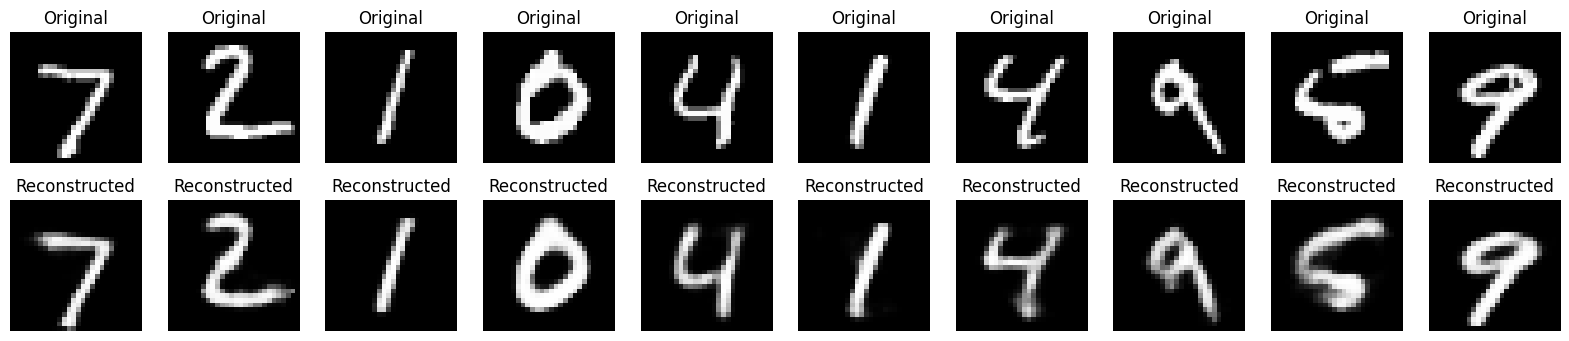

In [22]:
model.eval() # evaluation mode

with torch.no_grad():
    test_batch = next(iter(test_loader))[0].view(-1, 784).to(device) # iterator, get the next item (the first batch)
    recon, _, _ = model(test_batch)

    n = 10  # Number of digits to display
    plt.figure(figsize=(20, 4))
    
    for i in range(n):
        # Original digits
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(test_batch[i].cpu().view(28, 28), cmap='gray')
        plt.title("Original")
        plt.axis('off')
        
        # Reconstruction
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(recon[i].cpu().view(28, 28), cmap='gray')
        plt.title("Reconstructed")
        plt.axis('off')
    plt.show()

#### Sample from latent space

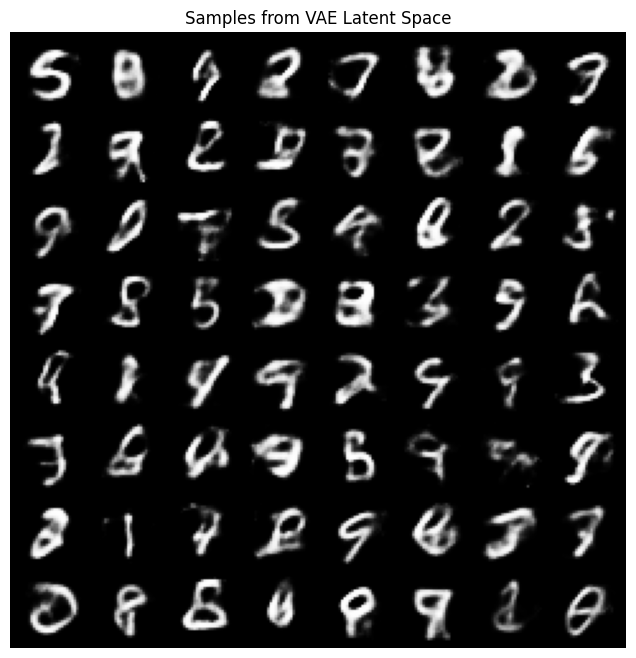

In [25]:
with torch.no_grad():
    z = torch.randn(64, 20).to(device) # draw from standard normal distribution
    # ToDo: decode z using the trained VAE
    sample = 
    sample = sample.view(64, 1, 28, 28)
    
    # Rescale from [-1, 1] to [0, 1] for display
    sample = (sample + 1) / 2

    grid = torchvision.utils.make_grid(sample, nrow=8)
    plt.figure(figsize=(8,8))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
    plt.axis('off')
    plt.title('Samples from VAE Latent Space')
    plt.show()

In [ ]:
# sample = model.decode(z).cpu()

Answers

In [ ]:
# ToDo: check PyTorch version
# print(torch.__version__)

In [ ]:
# ToDo: Please perform data normalisation on the entire mnist_raw dataset using `TransformedDataset`
# mnist_transformed = TransformedDataset(mnist_raw, transform)

In [ ]:
# ToDo: Please define other layers
# self.fc_mu = nn.Linear(hidden_dim, latent_dim)
# self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

In [ ]:
# ToDo: reparameterize
# z = torch.randn_like(mu).mul(std).add_(mu)

In [ ]:
# ToDo: please define the forward function; it will return recon_x, mu and logvar
# mu, logvar = self.encode(x)
# z = self.reparameterize(mu, logvar)
# recon_x = self.decode(z)

In [ ]:
# ToDo: KL Divergence, please use the equation provided
# KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

In [ ]:
# ToDo: decode z using the trained VAE
# sample = model.decode(z).cpu()

### Further Reading

Higgins, I., Matthey, L., Pal, A., Burgess, C., Glorot, X., Botvinick, M., Mohamed, S. and Lerchner, A., 2017, February. beta-vae: Learning basic visual concepts with a constrained variational framework. In International conference on learning representations.

Rybkin, O., Daniilidis, K. and Levine, S., 2021, July. Simple and effective VAE training with calibrated decoders. In International conference on machine learning (pp. 9179-9189). PMLR.

Van Den Oord, A. and Vinyals, O., 2017. Neural discrete representation learning. Advances in neural information processing systems, 30.